## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from google.colab import files

## 2. Load Dataset

In [20]:
from google.colab import files
# Prompt user to upload patients_data.csv
uploaded = files.upload()
df = pd.read_csv('patients_data.csv')
df.head()

Saving patients_data.csv to patients_data (4).csv


,Patient_ID,Month_of_Birth,Age,Sex,Occupation,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Reginol_Node_Positive,Survival_Months,Mortality_Status
0,A0012,12,68.0,Female,Teaching,T1,N1,IIA,Poorly differentiated,3,Regional,4.0,Positive,Positive,24.0,1,60,Alive
1,A0013,12,50.0,Female,Medical,T2,N2,IIIA,Moderately differentiated,2,Regional,35.0,Positive,Positive,14.0,5,62,Alive
2,A0014,11,58.0,Female,Engineering,T3,N3,IIIC,Moderately differentiated,2,Regional,63.0,Positive,Positive,14.0,7,75,Alive
3,A0015,3,58.0,Female,Technology,T1,N1,IIA,Poorly differentiated,3,Regional,18.0,Positive,Positive,2.0,1,84,Alive
4,A0016,1,47.0,Female,Multimedia,T2,N1,IIB,Poorly differentiated,3,Regional,41.0,Positive,Positive,3.0,1,50,Alive


## 3. Data Understanding - Descriptive Statistics and Variable Types

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              4024 non-null   object 
 1   Month_of_Birth          4024 non-null   int64  
 2   Age                     4015 non-null   float64
 3   Sex                     4020 non-null   object 
 4   Occupation              43 non-null     object 
 5   T_Stage                 4024 non-null   object 
 6   N_Stage                 4024 non-null   object 
 7   6th_Stage               4024 non-null   object 
 8   Differentiated          4024 non-null   object 
 9   Grade                   4024 non-null   int64  
 10  A_Stage                 4024 non-null   object 
 11  Tumor_Size              4021 non-null   float64
 12  Estrogen_Status         4024 non-null   object 
 13  Progesterone_Status     4024 non-null   object 
 14  Regional_Node_Examined  4023 non-null   

In [22]:
#Display list of coloumns
list(df.columns)

['Patient_ID',
 'Month_of_Birth',
 'Age',
 'Sex',
 'Occupation',
 'T_Stage',
 'N_Stage',
 '6th_Stage',
 'Differentiated',
 'Grade',
 'A_Stage',
 'Tumor_Size',
 'Estrogen_Status',
 'Progesterone_Status',
 'Regional_Node_Examined',
 'Reginol_Node_Positive',
 'Survival_Months',
 'Mortality_Status']

In [23]:
# Descriptive stats for categorical variables
df.describe(include='object')

,Patient_ID,Sex,Occupation,T_Stage,N_Stage,6th_Stage,Differentiated,A_Stage,Estrogen_Status,Progesterone_Status,Mortality_Status
count,4024,4020,43,4024,4024,4024,4024,4024,4024,4024,4024
unique,4024,2,40,4,3,5,4,2,2,2,7
top,A4035,Female,House Person,T2,N1,IIA,Moderately differentiated,Regional,Positive,Positive,Alive
freq,1,4001,2,1786,2732,1305,2351,3932,3755,3326,3399


In [24]:
# Display dataset shape (rows, columns)
print('Dataset Shape:', df.shape)
# Display variable types
print('\nVariable Types:\n', df.dtypes)
# Display descriptive statistics for numerical variables
print('\nDescriptive Statistics:\n', df.describe())

Dataset Shape: (4024, 18)

Variable Types:
 Patient_ID                 object
Month_of_Birth              int64
Age                       float64
Sex                        object
Occupation                 object
T_Stage                    object
N_Stage                    object
6th_Stage                  object
Differentiated             object
Grade                       int64
A_Stage                    object
Tumor_Size                float64
Estrogen_Status            object
Progesterone_Status        object
Regional_Node_Examined    float64
Reginol_Node_Positive       int64
Survival_Months             int64
Mortality_Status           object
dtype: object

Descriptive Statistics:
        Month_of_Birth          Age        Grade   Tumor_Size  \
count     4024.000000  4015.000000  4024.000000  4021.000000   
mean         6.481362    54.107098     2.150596    30.419299   
std          3.475442    11.715528     0.638234    21.161080   
min          1.000000   -50.000000     1.000000 

In [12]:
# Display unique values for each variable
for column in df.columns:
    print(f"Unique values in {column}:\n", df[column].unique(), "\n")

Unique values in Patient_ID:
 ['A0012' 'A0013' 'A0014' ... 'A4033' 'A4034' 'A4035'] 

Unique values in Month_of_Birth:
 [12 11  3  1  2  5  4  6  8  9  7 10] 

Unique values in Age:
 [ 68.  50.  58.  47.  51.  40.  69.  46.  65.  48.  62.  61.  56.  43.
  60.  57.  55.  63.  66.  53.  59.  54.  49.  64.  42.  nan  37.  67.
  31.  52.  33.  45.  38.  39.  36. 180.  41.  44. -50.  32.  34. 502.
  35.  30.  89.] 

Unique values in Sex:
 ['Female' '1' nan] 

Unique values in Occupation:
 ['Teaching' 'Medical' 'Engineering' 'Technology' 'Multimedia' 'Research'
 'House Person' 'Reporting' 'Development' 'Construction' 'Leisure'
 'Scoial work' 'Trading' 'Consultancy' 'Driving' 'Planning' 'Hospitality'
 'Travel' 'Agriculture' 'Manufacturing' 'Photography' 'Finance' 'Business'
 'Marketing' 'Training' 'Cleaning' 'Legal' 'Healthcare' 'Military' 'Sales'
 'Entertainment' 'Sports' 'Arts' 'Design' 'Maintenance' 'Management'
 'Human Resources' 'Administrative' 'Public' 'Politics' nan] 

Unique values i

In [25]:
# Count of missing values
df.isnull().sum()

,0
Patient_ID,0
Month_of_Birth,0
Age,9
Sex,4
Occupation,3981
T_Stage,0
N_Stage,0
6th_Stage,0
Differentiated,0
Grade,0


In [26]:
# Percent of missing values per column
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent

,0
Patient_ID,0.000000
Month_of_Birth,0.000000
Age,0.223658
Sex,0.099404
Occupation,98.931412
T_Stage,0.000000
N_Stage,0.000000
6th_Stage,0.000000
Differentiated,0.000000
Grade,0.000000


## 4. Data Understanding: Target Variable Distribution

In [27]:
# Numeric variable distribution
age_fig = px.histogram(df, x='Age', title='Age Distribution')
age_fig.show()


In [28]:
# categorical variable distribution
sex_counts = df['Sex'].value_counts().reset_index()
sex_counts.columns = ['Sex', 'Count']

sex_fig = px.bar(sex_counts, x='Sex', y='Count',
                 labels={'Sex': 'Sex', 'Count': 'Count'}, title='Sex Distribution')
sex_fig.show()


In [29]:
# showing data inconsistency
tumor_fig = px.box(df, y='Tumor_Size', title='Tumor Size Boxplot')
tumor_fig.show()


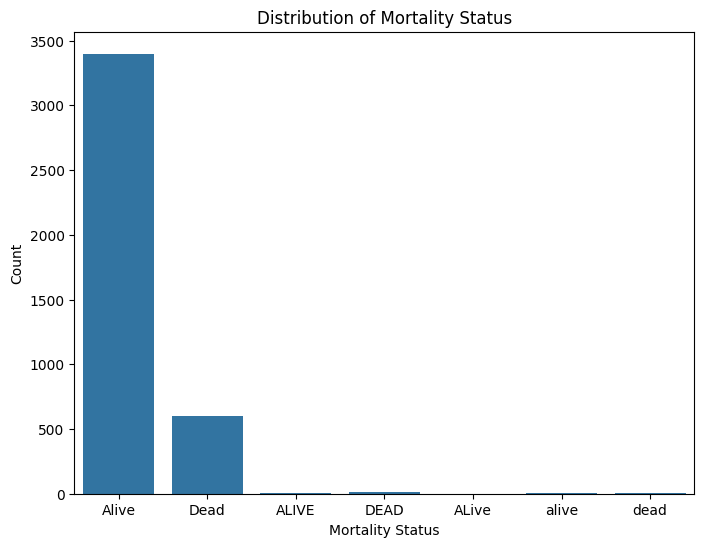

In [30]:
# Mortality status before Fixing
plt.figure(figsize=(8, 6))
sns.countplot(x='Mortality_Status', data=df)
plt.title('Distribution of Mortality Status')
plt.xlabel('Mortality Status')
plt.ylabel('Count')
plt.show()

## 5. Data Cleaning

In [31]:
# Drop unnessaasry coloumns
columns_to_drop = [ 'Patient_ID','Month_of_Birth', 'Occupation']
df = df.drop(columns=columns_to_drop)
# Verify columns after dropping
print('Remaining Columns:\n', df.columns)

Remaining Columns:
 Index(['Age', 'Sex', 'T_Stage', 'N_Stage', '6th_Stage', 'Differentiated',
       'Grade', 'A_Stage', 'Tumor_Size', 'Estrogen_Status',
       'Progesterone_Status', 'Regional_Node_Examined',
       'Reginol_Node_Positive', 'Survival_Months', 'Mortality_Status'],
      dtype='object')


reuse s1
def find_outliers_IQR(data):
q1=data.quantile(0.25)
q3-data.quantile(0.75)
IQR-q3-q1
outliers data[((data<(q1-1.5*IQR)) | (data>. (q3+1.5*IQR)))]
return outliers

outliers = find_outliers IQR(data['Variable Name'])
print("number of outliers: "+ str(len(outliers)))
outliers



In [32]:
#  Detect outliers using IQR

def find_outliers_IQR(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    IQR = q3 - q1
    outliers = data[((data < (q1 - 1.5 * IQR)) | (data > (q3 + 1.5 * IQR)))]
    return outliers

outliers_tumor = find_outliers_IQR(df['Tumor_Size'])
print("Number of outliers in Tumour Size:", len(outliers_tumor))

Number of outliers in Tumour Size: 221


In [33]:
# remove 3 outliers
before_shape = df.shape

outlier1_index = 5
outlier2_index = 10
outlier3_index = 42
df.drop(df.index[[outlier1_index, outlier2_index, outlier3_index]], inplace=True)

print("Before:", before_shape)
print("After:", df.shape)


Before: (4024, 15)
After: (4021, 15)


In [34]:
# Set display options to show all columns and up to 100 rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

##  Data Cleaning: Handle Missing Values

In [35]:
# Replace negative values in Age and Tumor_Size with their absolute values
print('Age Before Fix:\n', df['Age'].describe())
print('Tumor_Size Before Fix:\n', df['Tumor_Size'].describe())

df['Age'] = df['Age'].abs()
df['Tumor_Size'] = df['Tumor_Size'].abs()

# Display after fixing negative values
print('\nAge After Fix:\n', df['Age'].describe())
print('Tumor_Size After Fix:\n', df['Tumor_Size'].describe())

# Clip Age to realistic range (0 to 100 years)
df['Age'] = df['Age'].clip(0, 100)
print('\nAge After Fix:\n', df['Age'].describe())

# Verify no negative values remain and no ages are on relaistic range
print("Minimum Age:", df['Age'].min())
print("Minimum Tumor_Size:", df['Tumor_Size'].min())
print("Maximum Age:", df['Age'].max())

Age Before Fix:
 count    4012.000000
mean       54.102443
std        11.717089
min       -50.000000
25%        47.000000
50%        54.000000
75%        61.000000
max       502.000000
Name: Age, dtype: float64
Tumor_Size Before Fix:
 count    4018.000000
mean       30.428571
std        21.166034
min       -75.000000
25%        16.000000
50%        25.000000
75%        38.000000
max       140.000000
Name: Tumor_Size, dtype: float64

Age After Fix:
 count    4012.000000
mean       54.127368
std        11.601373
min        30.000000
25%        47.000000
50%        54.000000
75%        61.000000
max       502.000000
Name: Age, dtype: float64
Tumor_Size After Fix:
 count    4018.000000
mean       30.465903
std        21.112250
min         1.000000
25%        16.000000
50%        25.000000
75%        38.000000
max       140.000000
Name: Tumor_Size, dtype: float64

Age After Fix:
 count    4012.000000
mean       54.007228
std         9.036958
min        30.000000
25%        47.000000
50%    

In [36]:
print('Mortality_Status Unique Values Before:\n', df['Mortality_Status'].unique())
print('Mortality_Status Counts Before:\n', df['Mortality_Status'].value_counts())
# Standardize Mortality_Status to binary (Alive=1, Dead=0), handling all known variations
df['Mortality_Status'] = df['Mortality_Status'].replace({
    'Alive': 1, 'alive': 1, 'ALIVE': 1, 'ALive': 1,
    'Dead': 0, 'dead': 0, 'DEAD': 0
}).astype(int)
# Display after standardization
print('\nMortality_Status After:\n', df['Mortality_Status'].value_counts())

Mortality_Status Unique Values Before:
 ['Alive' 'Dead' 'ALIVE' 'DEAD' 'ALive' 'alive' 'dead']
Mortality_Status Counts Before:
 Mortality_Status
Alive    3397
Dead      597
DEAD       10
dead        8
ALIVE       5
alive       3
ALive       1
Name: count, dtype: int64

Mortality_Status After:
 Mortality_Status
1    3406
0     615
Name: count, dtype: int64


<ipython-input-36-bfb7a5c0e594>:4: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



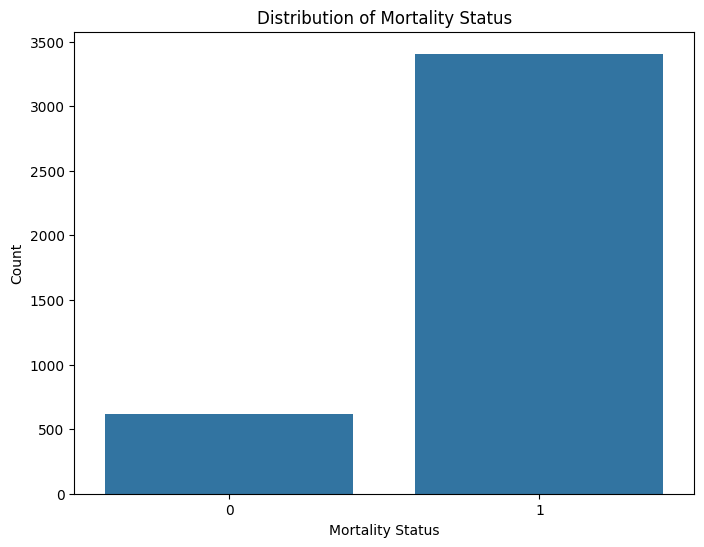

In [37]:
# Mortality Status after fixing
plt.figure(figsize=(8, 6))
sns.countplot(x='Mortality_Status', data=df)
plt.title('Distribution of Mortality Status')
plt.xlabel('Mortality Status')
plt.ylabel('Count')
plt.show()

In [38]:
# Display missing values before imputation
print('Missing Values Before:\n', df.isnull().sum())


Missing Values Before:
 Age                       9
Sex                       4
T_Stage                   0
N_Stage                   0
6th_Stage                 0
Differentiated            0
Grade                     0
A_Stage                   0
Tumor_Size                3
Estrogen_Status           0
Progesterone_Status       0
Regional_Node_Examined    1
Reginol_Node_Positive     0
Survival_Months           0
Mortality_Status          0
dtype: int64


In [40]:
# Inpute missing values
for column in df.columns:
    if df[column].dtype == 'object':

        df[column] = df[column].fillna(df[column].mode()[0])
    else:

        df[column] = df[column].fillna(df[column].median())
# Display missing values after imputation
print('\nMissing Values After:\n', df.isnull().sum())

df.shape

if df.isnull().sum().sum() == 0:
    print("Already clean: no missing values in the DataFrame. Nothing has to do for df.dropna()")
else:
    df = df.dropna()
    print("Missing values found and removed. New shape:", df.shape)



Missing Values After:
 Age                       0
Sex                       0
T_Stage                   0
N_Stage                   0
6th_Stage                 0
Differentiated            0
Grade                     0
A_Stage                   0
Tumor_Size                0
Estrogen_Status           0
Progesterone_Status       0
Regional_Node_Examined    0
Reginol_Node_Positive     0
Survival_Months           0
Mortality_Status          0
dtype: int64
Already clean: no missing values in the DataFrame. Nothing has to do for df.dropna()


# Encode Binary Categorical Variable

In [41]:
# Mortality_Status is already binary (0/1) after standardization
print( df['Mortality_Status'].value_counts(normalize=True) * 100)

Mortality_Status
1    84.705297
0    15.294703
Name: proportion, dtype: float64


# Convert Float to Integer

In [42]:
# Convert Age and Tumor_Size to integer
df['Age'] = df['Age'].astype(int)
df['Tumor_Size'] = df['Tumor_Size'].astype(int)
# Verify data types
print("Data Types after conversion:\n", df.dtypes)

Data Types after conversion:
 Age                         int64
Sex                        object
T_Stage                    object
N_Stage                    object
6th_Stage                  object
Differentiated             object
Grade                       int64
A_Stage                    object
Tumor_Size                  int64
Estrogen_Status            object
Progesterone_Status        object
Regional_Node_Examined    float64
Reginol_Node_Positive       int64
Survival_Months             int64
Mortality_Status            int64
dtype: object


## 9. Data Transformation: Encode Categorical Variables

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()
# Encode Tumor_Grade
df['Grade'] = le.fit_transform(df['Grade'])
# Display unique encoded values
print("Encoded Tumor_Grade values:\n", df['Grade'].unique())

Encoded Tumor_Grade values:
 [2 1 0 3]


In [ ]:
# Identify remaining categorical columns (excluding binary and ordinal)
categorical_cols = df.select_dtypes(include=['object']).columns
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
# Display the first 5 rows to verify encoding
print("Dataset after one-hot encoding:\n", df.head())

Dataset after one-hot encoding:
    Age  Grade  Tumor_Size  Regional_Node_Examined  Reginol_Node_Positive  \
0   68      2           4                    24.0                      1   
1   50      1          35                    14.0                      5   
2   58      1          63                    14.0                      7   
3   58      2          18                     2.0                      1   
4   47      2          41                     3.0                      1   

   Survival_Months  Mortality_Status  Sex_Female  T_Stage_T2  T_Stage_T3  \
0               60                 1        True       False       False   
1               62                 1        True        True       False   
2               75                 1        True       False        True   
3               84                 1        True       False       False   
4               50                 1        True        True       False   

   T_Stage_T4  N_Stage_N2  N_Stage_N3  6th_Stage_IIB 

## 10. Data Transformation: Scale Numerical Features

In [ ]:

# Identify numerical columns (excluding Mortality_Status and Survival_Months)
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
numeric_cols = [col for col in numeric_cols if col not in ['Mortality_Status', 'Survival_Months']]
# Initialize StandardScaler
scaler = StandardScaler()
# Scale numerical columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
# Display the first 5 rows to verify scaling
print("Dataset after scaling:\n", df.head())


Dataset after scaling:
         Age     Grade  Tumor_Size  Regional_Node_Examined  \
0  1.550325  1.330387   -1.253980                1.184029   
1 -0.443977 -0.236080    0.215056               -0.046389   
2  0.442379 -0.236080    1.541927               -0.046389   
3  0.442379  1.330387   -0.590544               -1.522891   
4 -0.776361  1.330387    0.499386               -1.399849   

   Reginol_Node_Positive  Survival_Months  Mortality_Status  Sex_Female  \
0              -0.618426               60                 1        True   
1               0.164352               62                 1        True   
2               0.555742               75                 1        True   
3              -0.618426               84                 1        True   
4              -0.618426               50                 1        True   

   T_Stage_T2  T_Stage_T3  T_Stage_T4  N_Stage_N2  N_Stage_N3  6th_Stage_IIB  \
0       False       False       False       False       False          False  

## 11. Prepare Datasets for Classification and Regression

In [ ]:
# Create classification dataset (exclude Survival_Months)
df_classification = df.drop(columns=['Survival_Months'])
# Display the first 5 rows
print("Classification Dataset Preview:\n", df_classification.head())
# Display shape
print("Classification Dataset Shape:", df_classification.shape)

Classification Dataset Preview:
         Age     Grade  Tumor_Size  Regional_Node_Examined  \
0  1.550325  1.330387   -1.253980                1.184029   
1 -0.443977 -0.236080    0.215056               -0.046389   
2  0.442379 -0.236080    1.541927               -0.046389   
3  0.442379  1.330387   -0.590544               -1.522891   
4 -0.776361  1.330387    0.499386               -1.399849   

   Reginol_Node_Positive  Mortality_Status  Sex_Female  T_Stage_T2  \
0              -0.618426                 1        True       False   
1               0.164352                 1        True        True   
2               0.555742                 1        True       False   
3              -0.618426                 1        True       False   
4              -0.618426                 1        True        True   

   T_Stage_T3  T_Stage_T4  N_Stage_N2  N_Stage_N3  6th_Stage_IIB  \
0       False       False       False       False          False   
1       False       False        True      

In [ ]:
# Create regression dataset (only deceased patients)
df_regression = df[df['Mortality_Status'] == 0].drop(columns=['Mortality_Status'])
# Display the first 5 rows
print("Regression Dataset Preview:\n", df_regression.head())
# Display shape
print("Regression Dataset Shape:", df_regression.shape)

Regression Dataset Preview:
          Age     Grade  Tumor_Size  Regional_Node_Examined  \
7  -1.551923 -0.236080   -0.021885               -0.661598   
40  0.331585 -0.236080    1.873645               -0.292473   
46 -1.330334 -0.236080   -1.017038                0.076652   
64  1.439530 -0.236080   -0.827485                0.199694   
66 -2.549074  1.330387    1.873645                1.060987   

    Reginol_Node_Positive  Survival_Months  Sex_Female  T_Stage_T2  \
7               -0.618426               14        True        True   
40               1.534215               42        True       False   
46              -0.422732               39        True       False   
64              -0.227037               60        True       False   
66               3.686855               44        True       False   

    T_Stage_T3  T_Stage_T4  N_Stage_N2  N_Stage_N3  6th_Stage_IIB  \
7        False       False       False       False           True   
40        True       False       False 

In [ ]:
# Save classification dataset (Task 26)
df_classification.to_csv('classification_data.csv', index=False)
# Save regression dataset (Task 26)
df_regression.to_csv('regression_data.csv', index=False)
# Download the files
files.download('classification_data.csv')
files.download('regression_data.csv')
# Confirm saving
print("Classification and regression datasets saved and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Classification and regression datasets saved and downloaded.
